# 12 — Biodiesel with Xavier initialization (Figure 5b)

**What changed.** One thing only: how the model's weights are drawn before training.

The ChemKAN edge coefficients are normally initialized as `randn(...) * 0.1`
(`chemkan/src/chemkan/kan/rbf.py:57`) — a fixed standard deviation that ignores layer
shape. This experiment re-initializes **every weight tensor** with Glorot/Xavier uniform,
`U(-a, a)` with `a = sqrt(6 / (fan_in + fan_out))`, via the new `--init xavier` flag on
the unchanged trainer `chemkan/scripts/train_biodiesel.py`.

Everything else is identical to the committed runs: same data, same 156-parameter
architecture, same Adam at `lr = 0.002`, same Tsit5 tolerances, same direct autograd,
same 10,000 epochs, same seed 0, same train-only min-max normalization. The `--init
default` path draws nothing extra from the RNG, so unflagged runs remain bit-identical
to every run trained before the flag existed (verified: epoch-0 loss
`1276.571044921875`).

**What is plotted.** Figure 5b — per-epoch training loss and noise-free test loss at
0/2/7/15 % observation noise — is reproduced twice:

1. **Xavier vs default ChemKAN**, the direct answer to "did the initialization matter".
2. **The original three-way layout**, with Xavier added alongside default ChemKAN and
   DeepONet, for continuity with the committed figure.

No training is performed by this notebook; it reads the run artifacts. The default
ChemKAN and DeepONet curves are the existing committed runs, unmodified.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import csv, json, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

ROOT = Path.cwd()
while not (ROOT / "chemkan" / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for folder in ("chemkan/src", "chemkan/scripts", "deeponet"):
    sys.path.insert(0, str(ROOT / folder))

from chemkan.model import KineticCore
from evaluate_biodiesel import evaluate_biodiesel
from train_biodiesel import apply_xavier_init

XAV  = ROOT / "results/experiments/biodiesel_xavier_init"
CKB  = ROOT / "results/reproduction/chemkan/biodiesel"
DON  = (ROOT / "results/reproduction/baselines/deeponet/biodiesel"
        / "reference_final_trunk_relu" / "noise")
FIGS = XAV / "figures"
TABS = XAV / "tables"
for d in (FIGS, TABS):
    d.mkdir(parents=True, exist_ok=True)

LEVELS = (0, 2, 7, 15)

def xavier_run(pct):
    return XAV / ("clean_seed0" if pct == 0 else f"noise{pct:02d}_seed0")

def default_run(pct):
    # The committed 0 % Figure-5b panel comes from the clean replay, which reproduces the
    # main run bitwise and carries the per-epoch test columns the main run lacks.
    return CKB / ("noise/clean_replay_seed0" if pct == 0 else f"noise/noise{pct:02d}_seed0")

def deeponet_run(pct):
    return DON / f"noise{pct:02d}_seed0"

print("Xavier runs   :", XAV.relative_to(ROOT))
for p in LEVELS:
    print(f"  {p:2d}% -> {xavier_run(p).relative_to(ROOT)}  vs  {default_run(p).relative_to(ROOT)}")

Xavier runs   : results/experiments/biodiesel_xavier_init
   0% -> results/experiments/biodiesel_xavier_init/clean_seed0  vs  results/reproduction/chemkan/biodiesel/noise/clean_replay_seed0
   2% -> results/experiments/biodiesel_xavier_init/noise02_seed0  vs  results/reproduction/chemkan/biodiesel/noise/noise02_seed0
   7% -> results/experiments/biodiesel_xavier_init/noise07_seed0  vs  results/reproduction/chemkan/biodiesel/noise/noise07_seed0
  15% -> results/experiments/biodiesel_xavier_init/noise15_seed0  vs  results/reproduction/chemkan/biodiesel/noise/noise15_seed0


## 1. What Xavier actually changes

With the base activation off (the paper count-matching 156-parameter configuration) the
kinetic core has exactly two trainable tensors, both RBF coefficient grids. For a 3-D
grid `(out, in, num_basis)` PyTorch reads `fan_in = in * num_basis` and
`fan_out = out * num_basis`. There are no bias vectors, so nothing is left uninitialized.

In [3]:
import math

torch.manual_seed(0)
core_def = KineticCore(species_dim=6, hidden_dim=4, num_basis=3, n_mu=2, use_base_act=False)
torch.manual_seed(0)
core_xav = KineticCore(species_dim=6, hidden_dim=4, num_basis=3, n_mu=2, use_base_act=False)
touched = apply_xavier_init(core_xav)

print(f"{'parameter':20} {'shape':>12} {'fan_in':>7} {'fan_out':>8} "
      f"{'default std':>12} {'Xavier bound':>13} {'Xavier std':>11} {'ratio':>7}")
init_rows = []
for (n, pd), (_, px) in zip(core_def.named_parameters(), core_xav.named_parameters()):
    out, inp, nb = pd.shape
    fi, fo = inp * nb, out * nb
    a = math.sqrt(6.0 / (fi + fo))
    sd, sx = pd.std().item(), px.std().item()
    print(f"{n:20} {str(tuple(pd.shape)):>12} {fi:>7} {fo:>8} {sd:>12.4f} "
          f"{a:>13.4f} {sx:>11.4f} {sx/sd:>7.2f}x")
    init_rows.append({"parameter": n, "shape": str(tuple(pd.shape)), "fan_in": fi,
                      "fan_out": fo, "default_std": sd, "xavier_bound": a,
                      "xavier_std": sx, "std_ratio": sx / sd})
    assert px.abs().max().item() <= a + 1e-6

print(f"\nre-initialized: {', '.join(touched)}")
print(f"parameters: {sum(p.numel() for p in core_xav.parameters())} (unchanged)")
with open(TABS / "xavier_init_statistics.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(init_rows[0])); w.writeheader(); w.writerows(init_rows)

parameter                   shape  fan_in  fan_out  default std  Xavier bound  Xavier std   ratio
add.edges.w_rbf         (4, 7, 3)      21       12       0.1013        0.4264      0.2364    2.33x
lean.edges.w_rbf        (6, 4, 3)      12       18       0.0960        0.4472      0.2496    2.60x

re-initialized: add.edges.w_rbf, lean.edges.w_rbf
parameters: 156 (unchanged)


In [4]:
# Every Xavier run must differ from its committed counterpart ONLY in initialization.
COMPARE = ["architecture", "parameter_count", "learning_rate", "epochs", "solver",
           "loss", "pinn", "normalization", "dataset", "seed", "sensitivity_backend"]
for pct in LEVELS:
    x = json.loads((xavier_run(pct) / "config.json").read_text())
    d = json.loads((default_run(pct) / "config.json").read_text())
    diffs = [k for k in COMPARE if x.get(k) != d.get(k)]
    assert not diffs, f"{pct}%: unexpected difference in {diffs}"
    assert x["initialization"] == "xavier"
    assert d.get("initialization") is None      # committed runs predate the flag
    assert (x["noise"] or {}).get("percent") == (d["noise"] or {}).get("percent")
    print(f"{pct:2d}%  xavier init={x['initialization']:7} params={x['parameter_count']} "
          f"lr={x['learning_rate']} epochs={x['epochs']} "
          f"noise={(x['noise'] or {}).get('percent')}  -> matches the committed run "
          f"in every compared field")

 0%  xavier init=xavier  params=156 lr=0.002 epochs=10000 noise=None  -> matches the committed run in every compared field
 2%  xavier init=xavier  params=156 lr=0.002 epochs=10000 noise=2  -> matches the committed run in every compared field
 7%  xavier init=xavier  params=156 lr=0.002 epochs=10000 noise=7  -> matches the committed run in every compared field
15%  xavier init=xavier  params=156 lr=0.002 epochs=10000 noise=15  -> matches the committed run in every compared field


## 2. Figure 5b — Xavier vs default ChemKAN

Raw per-epoch training and noise-free test loss. Triangles mark the noise-free test
minimum.

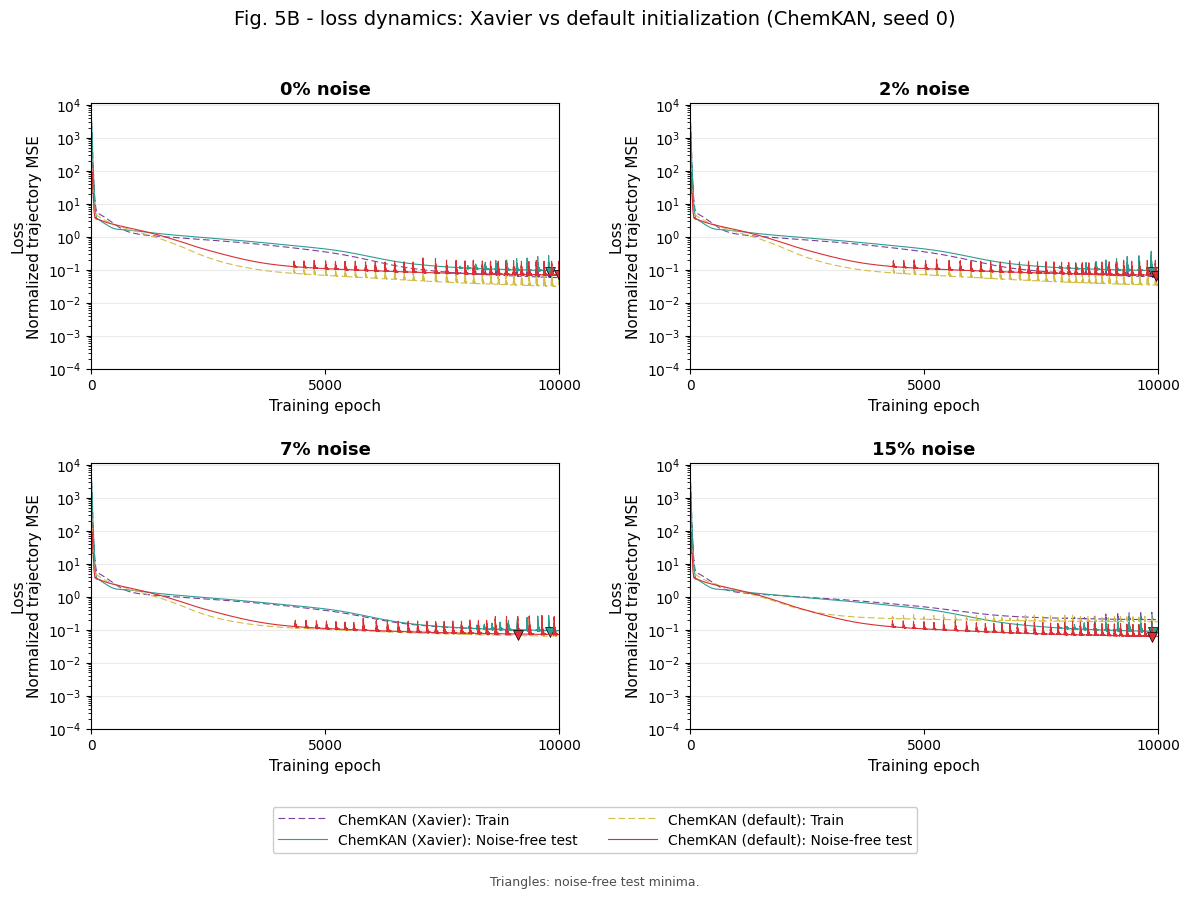

wrote results/experiments/biodiesel_xavier_init/figures/fig05b_xavier_vs_default_chemkan.png


In [5]:
def history(run_dir):
    r = list(csv.DictReader(open(run_dir / "history.csv")))
    return (np.array([float(x["epoch"]) for x in r]),
            np.array([float(x["total_loss"]) for x in r]),
            np.array([float(x["test_mse_clean"]) for x in r]))

COLORS = {
    "ChemKAN (Xavier)":  {"train": "#7B3FA0", "test": "#2E9E8F"},
    "ChemKAN (default)": {"train": "#D2BD45", "test": "#D92F35"},
    "DeepONet":          {"train": "#A76540", "test": "#55AD5B"},
}
LINES = {"train": (0, (6, 3)), "test": "-"}
LABELS = {"train": "Train", "test": "Noise-free test"}

def loss_dynamics_figure(series, title, filename):
    """One 2x2 Figure-5b grid. ``series`` maps a label to a function pct -> run dir."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
    spans = {}
    for ax, pct in zip(axes.flat, LEVELS):
        for name, getter in series.items():
            e, tr, te = history(getter(pct))
            late = e >= 0.8 * e.max()
            spans[(name, pct)] = (float(np.ptp(tr[late])), float(np.ptp(te[late])))
            for key, values in (("train", tr), ("test", te)):
                ax.plot(e, values, color=COLORS[name][key], ls=LINES[key], lw=0.8,
                        label=f"{name}: {LABELS[key]}")
            i = int(np.argmin(te))
            ax.plot(e[i], te[i], "v", color=COLORS[name]["test"], ms=7, mec="k", mew=0.5)
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
        ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10, labelOnlyBase=True))
        ax.set_xlabel("Training epoch", fontsize=11)
        ax.set_ylabel("Loss\nNormalized trajectory MSE", fontsize=11)
        ax.set_xticks([0, 5000, 10000]); ax.set_xlim(0, 10000)
        ax.tick_params(axis="both", which="major", labelsize=10, labelleft=True)
        ax.set_title(f"{pct}% noise", fontsize=13, fontweight="bold")
        ax.grid(axis="y", which="major", alpha=0.25)
    axes[0, 0].set_ylim(bottom=1e-4)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(series), loc="lower center",
               bbox_to_anchor=(0.5, 0.04), fontsize=10, handlelength=3.5,
               columnspacing=2.2, framealpha=1)
    fig.suptitle(title, fontsize=14, y=0.985)
    fig.text(0.5, 0.012, "Triangles: noise-free test minima.",
             ha="center", fontsize=9, color="0.3")
    fig.tight_layout(rect=(0, 0.12, 1, 0.96), h_pad=2.0, w_pad=2.0)
    for ext in ("pdf", "png"):
        fig.savefig(FIGS / f"{filename}.{ext}", dpi=150, bbox_inches="tight")
    plt.show()
    return spans

spans_ck = loss_dynamics_figure(
    {"ChemKAN (Xavier)": xavier_run, "ChemKAN (default)": default_run},
    "Fig. 5B - loss dynamics: Xavier vs default initialization (ChemKAN, seed 0)",
    "fig05b_xavier_vs_default_chemkan")
print("wrote", (FIGS / 'fig05b_xavier_vs_default_chemkan.png').relative_to(ROOT))

## 3. Figure 5b — three-way, with DeepONet

The committed layout with the Xavier curves added. DeepONet is unchanged from the
corrected `reference_final_trunk_relu` runs.

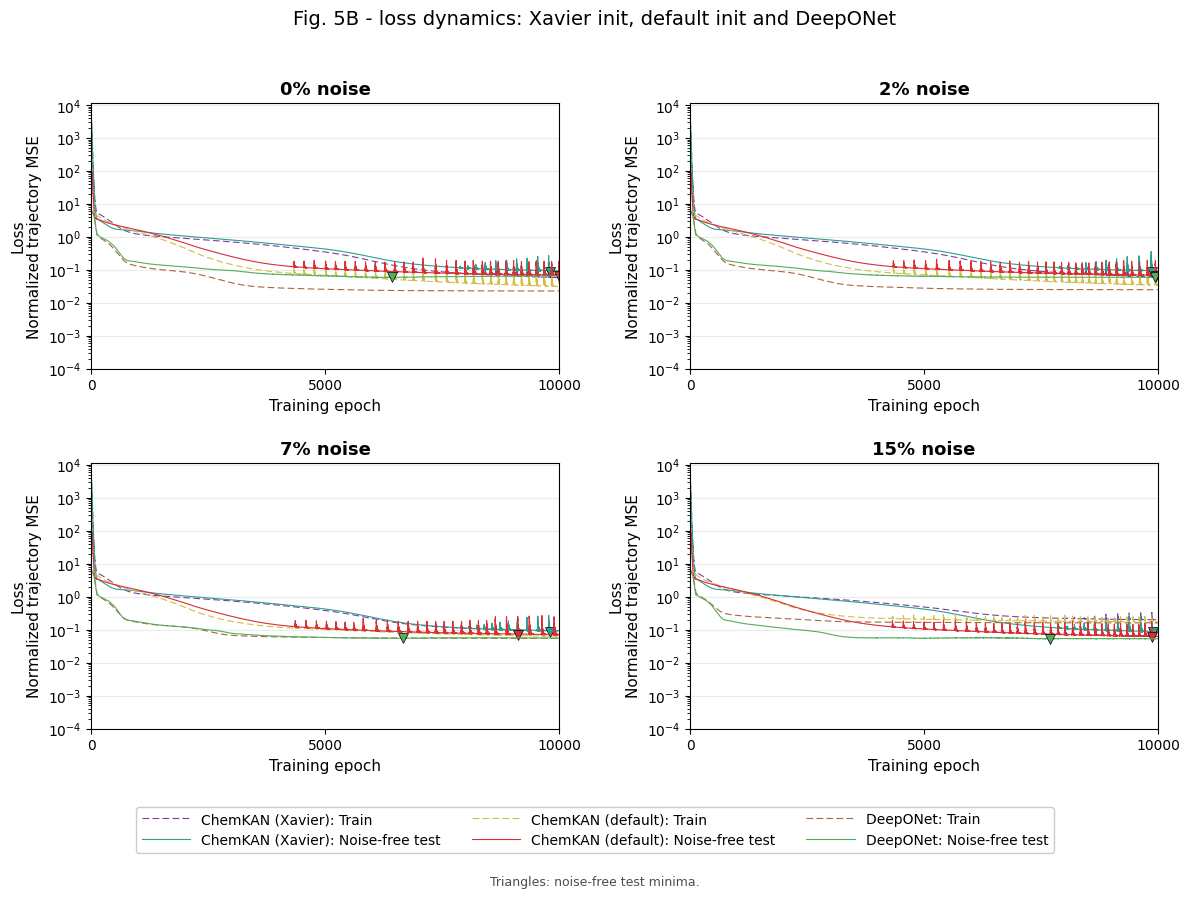

wrote results/experiments/biodiesel_xavier_init/figures/fig05b_xavier_three_way.png

late-training oscillation span (last 20% of epochs, RAW values):
noise model                  train span  clean-test span
   0% ChemKAN (Xavier)           0.1190           0.1832
   0% ChemKAN (default)          0.1188           0.1273
   0% DeepONet                   0.0004           0.0029
   2% ChemKAN (Xavier)           0.1925           0.2740
   2% ChemKAN (default)          0.1066           0.1274
   2% DeepONet                   0.0004           0.0010
   7% ChemKAN (Xavier)           0.1204           0.1808
   7% ChemKAN (default)          0.1894           0.2000
   7% DeepONet                   0.0003           0.0019
  15% ChemKAN (Xavier)           0.1323           0.1834
  15% ChemKAN (default)          0.1045           0.1164
  15% DeepONet                   0.0011           0.0017


In [6]:
spans_all = loss_dynamics_figure(
    {"ChemKAN (Xavier)": xavier_run, "ChemKAN (default)": default_run,
     "DeepONet": deeponet_run},
    "Fig. 5B - loss dynamics: Xavier init, default init and DeepONet",
    "fig05b_xavier_three_way")
print("wrote", (FIGS / 'fig05b_xavier_three_way.png').relative_to(ROOT))

print("\nlate-training oscillation span (last 20% of epochs, RAW values):")
print(f"{'noise':>5} {'model':20s} {'train span':>12s} {'clean-test span':>16s}")
for (n, pc), (a, b) in sorted(spans_all.items(), key=lambda kv: (kv[0][1], kv[0][0])):
    print(f"{pc:4d}% {n:20s} {a:12.4f} {b:16.4f}")

## 4. Overfitting assessment

The same diagnostic applied to the committed figure, reused verbatim from
`chemkan/scripts/diagnostics/refresh_biodiesel_reports.py` rather than reimplemented:
test rise > 10 %, smoothed training fall > 5 %, and the test minimum before 90 % of the
budget. These thresholds are our diagnostic choice, not the paper's.

In [7]:
from diagnostics.refresh_biodiesel_reports import assess_overfitting

assessment = {}
for pct in LEVELS:
    assessment[f"ChemKAN_xavier_{pct}pct"] = assess_overfitting(xavier_run(pct))
    assessment[f"ChemKAN_default_{pct}pct"] = assess_overfitting(default_run(pct))

print(f"{'run':28} {'min epoch':>10} {'test rise':>10} {'train fall':>11} {'meets criterion':>16}")
for name, a in assessment.items():
    print(f"{name:28} {a['min_epoch']:>10} {a['test_rise']:>9.1%} "
          f"{a['train_fall_after_min']:>10.1%} {str(a['overfitting']):>16}")

# The committed default-init numbers must reproduce exactly -- this notebook must not
# silently disagree with the figure already in the repository.
committed = json.loads((ROOT / "results/reproduction/tables"
                        / "biodiesel_fig5b_overfit_assessment.json").read_text())
for pct in LEVELS:
    got, want = assessment[f"ChemKAN_default_{pct}pct"], committed[f"ChemKAN_{pct}pct"]
    assert got["min_epoch"] == want["min_epoch"], (pct, got, want)
    assert abs(got["test_rise"] - want["test_rise"]) < 1e-12
print("\ndefault-init assessment reproduces the committed "
      "biodiesel_fig5b_overfit_assessment.json exactly")
(TABS / "xavier_fig5b_overfit_assessment.json").write_text(json.dumps(assessment, indent=2) + "\n")
print("wrote", (TABS / 'xavier_fig5b_overfit_assessment.json').relative_to(ROOT))

run                           min epoch  test rise  train fall  meets criterion
ChemKAN_xavier_0pct                9796     10.0%       8.0%            False
ChemKAN_default_0pct               9986    125.3%       0.0%            False
ChemKAN_xavier_2pct                9875      9.0%       0.2%            False
ChemKAN_default_2pct               9960      5.2%       0.0%            False
ChemKAN_xavier_7pct                9795      6.9%       5.2%            False
ChemKAN_default_7pct               9118      3.5%       3.6%            False
ChemKAN_xavier_15pct               9885      6.2%       0.0%            False
ChemKAN_default_15pct              9881      1.6%       0.0%            False

default-init assessment reproduces the committed biodiesel_fig5b_overfit_assessment.json exactly
wrote results/experiments/biodiesel_xavier_init/tables/xavier_fig5b_overfit_assessment.json


## 5. Converged losses at the final checkpoint

Evaluated through `evaluate_biodiesel`, the same function the reproduction uses: a full
rollout from the original initial conditions, scored against the noisy observations
(Eq. 18) and against the clean trajectories (Eq. 22).

In [8]:
rows = []
for pct in LEVELS:
    npct = None if pct == 0 else pct
    for label, getter in (("xavier", xavier_run), ("default", default_run)):
        r = {"noise_percent": pct, "init": label}
        for split in ("train", "test"):
            res = evaluate_biodiesel(getter(pct) / "checkpoint_final.pt", split=split,
                                     device="cpu", noise_percent=npct)
            r[f"{split}_mse_noisy"] = res["mse"]
            r[f"{split}_mse_clean"] = res["mse_clean"]
        rows.append(r)

print(f"{'noise':>5} {'init':>8} {'train (noisy)':>14} {'test (noisy)':>13} "
      f"{'test (clean)':>13}")
for r in rows:
    print(f"{r['noise_percent']:4d}% {r['init']:>8} {r['train_mse_noisy']:>14.6f} "
          f"{r['test_mse_noisy']:>13.6f} {r['test_mse_clean']:>13.6f}")

print(f"\n{'noise':>5} {'train ratio':>12} {'clean-test ratio':>17}   (xavier / default)")
for pct in LEVELS:
    x = next(r for r in rows if r["noise_percent"] == pct and r["init"] == "xavier")
    d = next(r for r in rows if r["noise_percent"] == pct and r["init"] == "default")
    print(f"{pct:4d}% {x['train_mse_noisy']/d['train_mse_noisy']:>12.3f} "
          f"{x['test_mse_clean']/d['test_mse_clean']:>17.3f}")

with open(TABS / "xavier_final_losses.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0])); w.writeheader(); w.writerows(rows)
print("\nwrote", (TABS / 'xavier_final_losses.csv').relative_to(ROOT))

noise     init  train (noisy)  test (noisy)  test (clean)
   0%   xavier       0.057611      0.091591      0.091591
   0%  default       0.062017      0.081401      0.081401
   2%   xavier       0.060276      0.096211      0.093611
   2%  default       0.033856      0.070366      0.068679
   7%   xavier       0.090400      0.126649      0.093726
   7%  default       0.062722      0.102406      0.070680
  15%   xavier       0.199499      0.236410      0.087940
  15%  default       0.172369      0.201094      0.062277

noise  train ratio  clean-test ratio   (xavier / default)
   0%        0.929             1.125
   2%        1.780             1.363
   7%        1.441             1.326
  15%        1.157             1.412

wrote results/experiments/biodiesel_xavier_init/tables/xavier_final_losses.csv


### A single checkpoint is not enough

The late-training oscillation spans printed above (ChemKAN: 0.10–0.27) are **larger than
the difference between the two initializations**, so the final-checkpoint table is
dominated by where in its oscillation cycle each run happened to stop. The comparison
below repeats it on the median of the **last 20 % of epochs**, which is what the verdict
should rest on.


In [9]:
late = {}
for pct in LEVELS:
    for label, getter in (("xavier", xavier_run), ("default", default_run)):
        e, tr, te = history(getter(pct))
        m = e >= 0.8 * e.max()
        late[(label, pct)] = (float(np.median(tr[m])), float(np.median(te[m])))

print(f"{'noise':>5} {'init':>8} {'train median':>14} {'clean-test median':>19}")
for pct in LEVELS:
    for label in ("xavier", "default"):
        a, b = late[(label, pct)]
        print(f"{pct:4d}% {label:>8} {a:>14.6f} {b:>19.6f}")

print(f"\n{'noise':>5} {'train ratio':>12} {'test ratio':>11}   "
      f"{'|final-ckpt gap|':>16} {'default osc. span':>18}  gap vs span")
late_rows = []
for pct in LEVELS:
    xt, xe = late[("xavier", pct)]
    dt, de = late[("default", pct)]
    xr = next(r for r in rows if r["noise_percent"] == pct and r["init"] == "xavier")
    dr = next(r for r in rows if r["noise_percent"] == pct and r["init"] == "default")
    gap = abs(xr["train_mse_noisy"] - dr["train_mse_noisy"])
    span = spans_ck[("ChemKAN (default)", pct)][0]
    print(f"{pct:4d}% {xt/dt:>12.3f} {xe/de:>11.3f}   {gap:>16.4f} {span:>18.4f}"
          f"  {gap/span:>6.2f}x")
    late_rows.append({"noise_percent": pct, "xavier_train_median": xt,
                      "default_train_median": dt, "xavier_test_median": xe,
                      "default_test_median": de, "train_ratio": xt / dt,
                      "test_ratio": xe / de, "final_checkpoint_gap": gap,
                      "default_late_oscillation_span": span})

with open(TABS / "xavier_late_window_comparison.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(late_rows[0])); w.writeheader(); w.writerows(late_rows)
print("\nwrote", (TABS / 'xavier_late_window_comparison.csv').relative_to(ROOT))
print("A 'gap vs span' well below 1 means the final-checkpoint difference is smaller than\n"
      "the run's own epoch-to-epoch swing, i.e. not a meaningful single-point comparison.")


noise     init   train median   clean-test median
   0%   xavier       0.066090            0.100868
   0%  default       0.035783            0.073063
   2%   xavier       0.068908            0.101156
   2%  default       0.038607            0.072723
   7%   xavier       0.099010            0.100586
   7%  default       0.067125            0.074527
  15%   xavier       0.208344            0.096601
  15%  default       0.176976            0.067508

noise  train ratio  test ratio   |final-ckpt gap|  default osc. span  gap vs span
   0%        1.847       1.381             0.0044             0.1188    0.04x
   2%        1.785       1.391             0.0264             0.1066    0.25x
   7%        1.475       1.350             0.0277             0.1894    0.15x
  15%        1.177       1.431             0.0271             0.1045    0.26x

wrote results/experiments/biodiesel_xavier_init/tables/xavier_late_window_comparison.csv
A 'gap vs span' well below 1 means the final-checkpoint differenc

## 6. Summary

In [10]:
def better(key_idx):
    return sum(late[("xavier", p)][key_idx] < late[("default", p)][key_idx] for p in LEVELS)

lb_tr, lb_te = better(0), better(1)
ratios_tr = [late[("xavier", p)][0] / late[("default", p)][0] for p in LEVELS]
ratios_te = [late[("xavier", p)][1] / late[("default", p)][1] for p in LEVELS]

ck_tr = sum(next(r for r in rows if r["noise_percent"] == p and r["init"] == "xavier")["train_mse_noisy"]
            < next(r for r in rows if r["noise_percent"] == p and r["init"] == "default")["train_mse_noisy"]
            for p in LEVELS)
ck_te = sum(next(r for r in rows if r["noise_percent"] == p and r["init"] == "xavier")["test_mse_clean"]
            < next(r for r in rows if r["noise_percent"] == p and r["init"] == "default")["test_mse_clean"]
            for p in LEVELS)

print("SUMMARY  (seed 0, 10,000 epochs, only the weight initialization differs)")
print("")
print(f"  Xavier weights start {init_rows[0]['std_ratio']:.1f}-{init_rows[1]['std_ratio']:.1f}x "
      f"wider than the default randn*0.1 draw (156 parameters either way).")
print("")
print("  PRIMARY -- median over the last 20% of epochs:")
print(f"    training loss   : Xavier better at {lb_tr}/{len(LEVELS)} noise levels, "
      f"median ratio {np.median(ratios_tr):.3f}")
print(f"    clean-test loss : Xavier better at {lb_te}/{len(LEVELS)} noise levels, "
      f"median ratio {np.median(ratios_te):.3f}")
print("")
print(f"  Single final checkpoint (oscillation-dominated, shown for completeness):")
print(f"    training {ck_tr}/{len(LEVELS)}, clean-test {ck_te}/{len(LEVELS)}")
print("")
xo = [k for k, a in assessment.items() if k.startswith("ChemKAN_xavier") and a["overfitting"]]
do = [k for k, a in assessment.items() if k.startswith("ChemKAN_default") and a["overfitting"]]
print(f"  Runs meeting our overfitting criterion: Xavier {xo or 'none'}, default {do or 'none'}")
print("")
print("  Xavier also spends most of training ABOVE the default curve at every noise level")
print("  (see the figures): the wider initial weights cost a long early phase that is only")
print("  partly recovered by 10,000 epochs.")
print("")
print("  ONE SEED. Initialization changes the whole optimization trajectory, so this shows")
print("  Xavier did not help here; it does not establish a general ordering.")


SUMMARY  (seed 0, 10,000 epochs, only the weight initialization differs)

  Xavier weights start 2.3-2.6x wider than the default randn*0.1 draw (156 parameters either way).

  PRIMARY -- median over the last 20% of epochs:
    training loss   : Xavier better at 0/4 noise levels, median ratio 1.630
    clean-test loss : Xavier better at 0/4 noise levels, median ratio 1.386

  Single final checkpoint (oscillation-dominated, shown for completeness):
    training 1/4, clean-test 0/4

  Runs meeting our overfitting criterion: Xavier none, default none

  Xavier also spends most of training ABOVE the default curve at every noise level
  (see the figures): the wider initial weights cost a long early phase that is only
  partly recovered by 10,000 epochs.

  ONE SEED. Initialization changes the whole optimization trajectory, so this shows
  Xavier did not help here; it does not establish a general ordering.
